# Minimering af gennemløbstid i et jobshop med PROC OPTMODEL

## Resumé

En lille celle til diskret fremstilling skal føre fire emner — et **Beslag**, en **Flange**, et **Hus** og en **Aksel** — gennem hver deres faste sekvens af tre bearbejdningsoperationer, mens de deler fire maskiner med enkeltkapacitet (**Sav**, **Fræser**, **Bor**, **Sliber**). Ingen maskine kan køre to operationer på én gang, og hvert emnes operationer skal følge deres teknologiske rækkefølge. Vi formulerer den gennemløbstidsminimerende plan som et blandet heltalsprogram i **PROC OPTMODEL** — starttidsvariable, slut-til-start-forrangsbetingelser og disjunktive (big-*M*) ikke-overlap-betingelser mellem hvert par af operationer, der deler en maskine — og løser det til bevist optimalitet.

MILP-løseren returnerer en **optimal gennemløbstid på 120 minutter** (`Solution Status = Optimal`, `Objective Value = 120`). Den resulterende plan pakker alle tolv operationer, så hver maskine bearbejder højst ét emne ad gangen, og hvert emne følger sin krævede teknologiske rækkefølge. To operationer slutter præcis ved minut 120 — Beslagets slibning og Husets fræsning — så både Sliber- og Fræser-maskinen ligger på den kritiske vej, der fastlægger planens længde.

## Datakilder

Alle data defineres i selve notebooken — ingen eksterne filer eller netværk.

| Datasæt | Rækker | Nøglevariable | Beskrivelse |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Én række pr. operation (4 emner × 3 operationer). `machine` (1–4) er den maskine, operationen kræver; `dur` er dens behandlingstid i minutter; `jobname`/`mname` er læselige emne- og maskineetiketter. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL-output: det optimale start- og slutminut for hver operation. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` flettet med de løste tider, sorteret efter maskine og derefter start — den menneskeligt læsbare plan. |
| `mk` | 1 | `makespan` | Den realiserede gennemløbstid (seneste sluttidspunkt). |

## Planlægningsproblemet

I et **jobshop** passerer flere emner ("jobs") hver gennem en fast sekvens af operationer, og hver operation kører på en bestemt maskine. To operationer kan ikke optage samme maskine på samme tid (maskinerne er *unære* ressourcer), og inden for et emne skal operationerne overholde deres teknologiske rækkefølge. Planlæggeren ønsker starttider for hver operation, der overholder begge regler, samtidig med at den samlede planlængde — **gennemløbstiden** — holdes så lille som muligt.

Dette er et klassisk disjunktivt planlægningsproblem. Vi modellerer det som et blandet heltalsprogram:

- en kontinuert-men-heltallig **starttid** `s[o]` for hver operation og en gennemløbstidsvariabel `Cmax`;
- **forrang**: operation *k+1* i et emne starter ikke tidligere, end operation *k* slutter;
- **disjunktiv maskinekapacitet**: for hvert par af operationer, der deler en maskine, afgør en binær `y`, hvilken der kommer først, og et big-*M*-led slår den inaktive rækkefølge fra — så de to operationer aldrig kan overlappe;
- **målfunktion**: minimér `Cmax`, som tvinges til at være mindst lig med hver operations sluttidspunkt.

PROC OPTMODEL er SAS/OR's algebraiske modelleringsprocedure; dens MILP-løser finder den *beviseligt optimale* korteste plan.

> **En bemærkning om PROC CLP.** SAS tilbyder også PROC CLP, en constraint-logic > programming-motor med dedikeret planlægningssyntaks (aktiviteter, > ressourcer, forrang). OPTMODEL-MILP-formuleringen her løser det > identiske problem og returnerer et certifikat for optimalitet, hvilket CLP's > feasibility-søgning ikke gør.

## Trin 1 — Definér shop-instansen

Fire emner, tre operationer hver, på fire maskiner. Hver række fastlægger den maskine, en operation kræver, og dens behandlingstid i minutter. Et emnes operationer er anført i teknologisk rækkefølge (`opnum` 1, 2, 3).

In [1]:
data jobshop;
    LÆNGDE jobname $10 mname $12;
    INDDATA op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Beslag  Sav
2  1 2 3 40 Beslag  Bor
3  1 3 4 20 Beslag  Sliber
4  2 1 2 35 Flange  Fræser
5  2 2 3 25 Flange  Bor
6  2 3 1 15 Flange  Sav
7  3 1 3 30 Hus  Bor
8  3 2 1 20 Hus  Sav
9  3 3 2 45 Hus  Fræser
10 4 1 1 20 Aksel  Sav
11 4 2 2 30 Aksel  Fræser
12 4 3 4 25 Aksel  Sliber
;
KØR;

PROCEDURE UDSKRIV data=jobshop noobs;
    TITEL 'Job-shop-instans: 4 emner, 3 operationer hver, 4 maskiner';
    VARIABEL op jobname opnum mname dur;
    MÆRKAT op="Op." jobname="Emne" opnum="Trin" mname="Maskine" dur="Varighed (min)";
KØR;

                               Job-shop-instans: 4 emner, 3 operationer hver, 4 maskiner                                

Op.    Emne  Trin  Maskine  Varighed (min)
  1  Beslag     1  Sav                  25
  2  Beslag     2  Bor                  40
  3  Beslag     3  Sliber               20
  4  Flange     1  Fræser               35
  5  Flange     2  Bor                  25
  6  Flange     3  Sav                  15
  7  Hus        1  Bor                  30
  8  Hus        2  Sav                  20
  9  Hus        3  Fræser               45
 10  Aksel      1  Sav                  20
 11  Aksel      2  Fræser               30
 12  Aksel      3  Sliber               25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Trin 2 — Løs den gennemløbstidsminimerende plan med PROC OPTMODEL

OPTMODEL læser instansen, bygger start- og rækkefølgevariablene, opstiller forrangs- og disjunktive betingelser og minimerer gennemløbstiden med sin MILP-løser. Big-*M*-horisonten `H` er det samlede arbejdsindhold — en sikker øvre grænse for enhver starttid. Løseren rapporterer den **optimale** målfunktion; vi skriver de valgte start- og sluttider til `sched`.

In [2]:
PROCEDURE optmodel;
    SÆT OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ data jobshop INTO OPS=[op] job opnum machine dur;

    /* en sikker big-M-horisont = samlet arbejdsindhold */
    num H = sum{o IN OPS} dur[o];

    VARIABEL s{OPS} >= 0 integer;     /* operationens starttid (minutter) */
    VARIABEL Cmax >= 0;               /* gennemløbstid */

    /* teknologisk rækkefølge: operation k+1 starter efter operation k slutter */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* gennemløbstiden dominerer hver operations sluttidspunkt */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunktiv maskinekapacitet: for hvert operationspar der deler en
       maskine, fastlægger binær y rækkefølgen; big-M slækker den anden */
    VARIABEL y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE data sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                               Job-shop-instans: 4 emner, 3 operationer hver, 4 maskiner                                


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Trin 3 — Saml den læselige plan

Flet de løste tider tilbage på emne- og maskineetiketterne, sortér efter maskine og derefter starttid, og udskriv planen. Gennemløbstiden er det største sluttidspunkt på tværs af alle operationer.

In [3]:
PROCEDURE SORTER data=jobshop out=jobs2; EFTER op; KØR;
PROCEDURE SORTER data=sched   out=sol;   EFTER op; KØR;

data schedule;
    SAMMENFLET jobs2 sol;
    EFTER op;
KØR;

PROCEDURE SORTER data=schedule; EFTER mname START; KØR;

PROCEDURE UDSKRIV data=schedule noobs;
    TITEL 'Optimal plan: start/slut (minutter) for hver operation';
    VARIABEL jobname opnum mname dur START FINISH;
    MÆRKAT jobname="Emne" opnum="Trin" mname="Maskine" dur="Varighed (min)" START="Start (min)" FINISH="Slut (min)";
KØR;

PROCEDURE GENNEMSNIT data=schedule MAX NOPRINT;
    VARIABEL FINISH;
    UDDATA out=mk(FJERN=_type_ _freq_) MAX=makespan;
KØR;

PROCEDURE UDSKRIV data=mk noobs;
    TITEL 'Minimal gennemløbstid (seneste operationsslut, minutter)';
    MÆRKAT makespan="Gennemløbstid (min)";
KØR;

                                 Optimal plan: start/slut (minutter) for hver operation                                 

  Emne  Trin  Maskine  Varighed (min)  Start (min)  Slut (min)
Hus        1  Bor                  30            0          30
Flange     2  Bor                  25           35          60
Beslag     2  Bor                  40           60         100
Flange     1  Fræser               35            0          35
Aksel      2  Fræser               30           35          65
Hus        3  Fræser               45           75         120
Aksel      1  Sav                  20            0          20
Beslag     1  Sav                  25           20          45
Hus        2  Sav                  20           45          65
Flange     3  Sav                  15           65          80
Aksel      3  Sliber               25           65          90
Beslag     3  Sliber               20          100         120

                                Minimal gennemløbstid (sen


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Trin 4 — Visualisér planen

Vi giver hver operation en ordinal **plads** (sorteret efter maskine og derefter start) og tegner dens tidsvindue som en flydende bjælke: bjælken strækker sig fra operationens startminut til dens slutminut. Pladserne 1–3 er Bor, 4–6 Fræser, 7–10 Sav og 11–12 Sliber. Tabellen lige nedenunder navngiver emnet på hver plads, så diagrammet og tabellen læses sammen. Bjælker på samme maskine overlapper aldrig i tid — den disjunktive betingelse gjort synlig.

                             Plan efter plads (pladsrækkefølge matcher diagrammet nedenfor)                             

Plads  Maskine    Emne  Start (min)  Slut (min)
    1  Bor      Hus               0          30
    2  Bor      Flange           35          60
    3  Bor      Beslag           60         100
    4  Fræser   Flange            0          35
    5  Fræser   Aksel            35          65
    6  Fræser   Hus              75         120
    7  Sav      Aksel             0          20
    8  Sav      Beslag           20          45
    9  Sav      Hus              45          65
   10  Sav      Flange           65          80
   11  Sliber   Aksel            65          90
   12  Sliber   Beslag          100         120

                             Plan efter plads (pladsrækkefølge matcher diagrammet nedenfor)                             




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


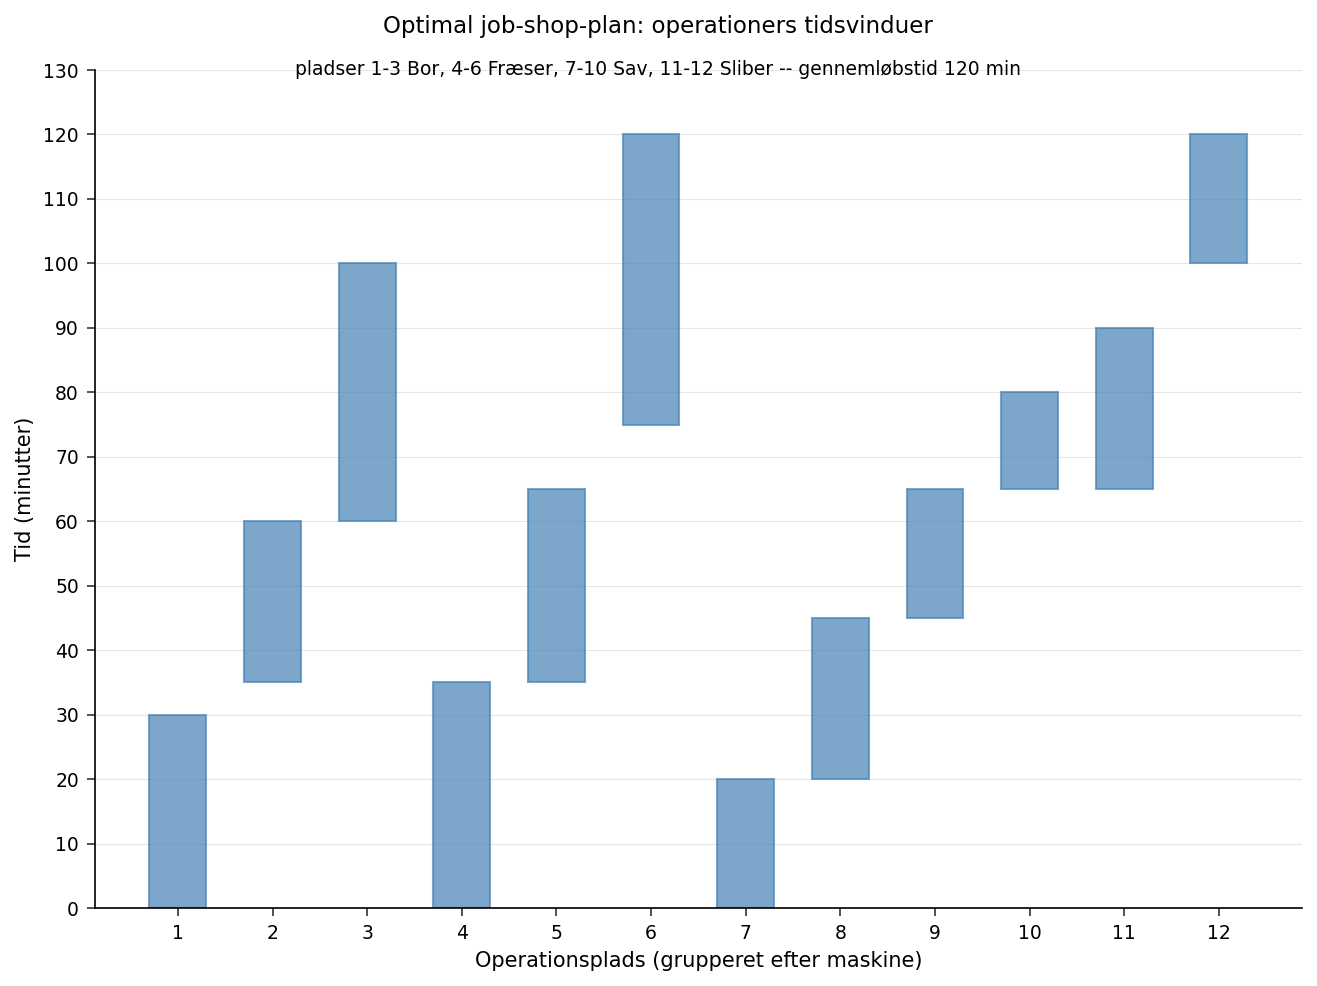

In [4]:
data ganttdata;
    SÆT schedule;
    slot + 1;
KØR;

PROCEDURE UDSKRIV data=ganttdata noobs;
    TITEL 'Plan efter plads (pladsrækkefølge matcher diagrammet nedenfor)';
    VARIABEL slot mname jobname START FINISH;
    MÆRKAT slot="Plads" mname="Maskine" jobname="Emne" START="Start (min)" FINISH="Slut (min)";
KØR;

PROCEDURE SGPLOT data=ganttdata noautolegend;
    TITEL 'Optimal job-shop-plan: operationers tidsvinduer';
    title2 'pladser 1-3 Bor, 4-6 Fræser, 7-10 Sav, 11-12 Sliber -- gennemløbstid 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS MÆRKAT='Operationsplads (grupperet efter maskine)' integer
          VALUES=(1 TIL 12 EFTER 1);
    YAXIS MÆRKAT='Tid (minutter)' grid VALUES=(0 TIL 130 EFTER 10);
KØR;
TITEL;

## Fortolkning af resultaterne

- **Optimalitet.** MILP-løseren returnerede `Solution Status = Optimal` med `Objective Value = 120`, så **120 minutter er den beviseligt korteste mulige gennemløbstid** for denne instans — ingen plan kan slutte hurtigere. Dette certifikat er, hvad den matematisk-programmeringsformulering giver dig frem for en ren feasibility-søgning.

- **Planen overholder hver betingelse.** Ved at læse tabellen efter maskine overlapper ingen to operationer på samme maskine (f.eks. på Sav: Aksel 0–20, Beslag 20–45, Hus 45–65, Flange 65–80), og hvert emne kører i teknologisk rækkefølge (f.eks. Hus: Bor 0–30, derefter Sav 45–65, derefter Fræser 75–120). Den flydende bjælke-graf viser det samme: inden for hver maskines pladsbånd flisebelægger tidsvinduerne uden kollision.

- **Hvad der fastlægger planlængden.** To operationer slutter præcis ved minut 120 — Beslagets Sliber (plads 12) og Husets Fræser (plads 6). Begge rører gennemløbstiden, så Sliber- og Fræser-maskinerne sidder på den kritiske vej; at barbere gennemløbstiden yderligere ville kræve en ændring af selve instansen (hurtigere operationer, en ekstra maskine eller lempet forrang), ikke blot en ny sekvensering.

- **Hvordan den skalerer.** Formuleringen vokser naturligt: tilføj en maskine som endnu en værdi af `machine`, tilføj emner som flere rækker i `jobshop`, eller modellér frigivelses- og forfaldsdatoer ved at afgrænse `s[o]` og tilføje forfaldsdato-betingelser. At tillade en maskine at køre flere jobs på én gang (kapacitet >1) erstatter den parvise disjunktion med en kumulativ-ressource-betingelse. Den samme OPTMODEL-MILP håndterer så rigere shop-floor-regler uden at ændre løseren.